# NB07 — Condition-Specific Growth Prediction

**Project**: `genotype_to_phenotype_enigma`  
**Depends on**: NB05 (features), NB06 (variance partitioning diagnostic)

## Goal

Build a predictor that works for NEW genomes on SPECIFIC conditions — the core project deliverable. NB06 showed that with n=7 anchor strains, the ENIGMA-only model learns genome scale (25.3%) and condition class (45.9%) but not condition-specific gene effects. This notebook tests three approaches to overcome that bottleneck.

## Key Results

### Model comparison (binary growth prediction)

| Model | AUC | Accuracy | Coverage | n pairs | What it predicts |
|---|---|---|---|---|---|
| ENIGMA-only GBDT (NB06 M3) | 0.633 | — | 100% | 486 | "Big genomes grow on amino acids" |
| **GapMind baseline** | 0.646 | **78.8%** | 24.3% | 118 | "Complete pathway → growth" |
| CSP transfer (all) | 0.636 | 59.3% | 100% | 486 | Generic KO signal (no condition match) |
| **CSP transfer (matched)** | **0.800** | **76.8%** | 23% | 112 | "These KOs predict THIS condition" |
| CSP internal (5-fold CV) | 0.858 | — | CSP | 17,568 | Ceiling with sufficient data |

**The central finding**: Condition-specific prediction IS achievable (AUC 0.80-0.86) when the model knows which condition is being tested AND has sufficient training data. It fails (AUC ~0.63) when using generic KO features or when the condition isn't in the training set.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image

DATA = Path('../data')
FIG = Path('../figures')
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 200)


## 1. Model comparison

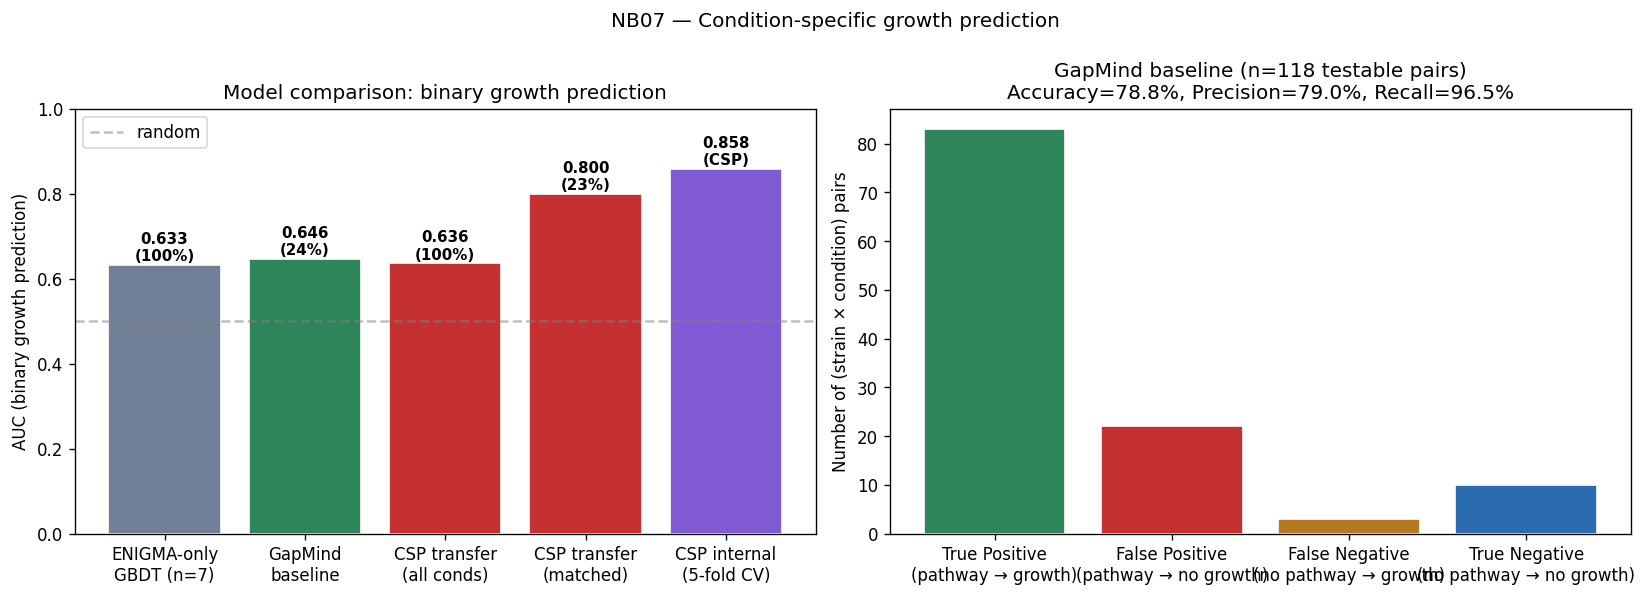

In [2]:
Image(filename=str(FIG / 'NB07_model_comparison.png'))

### GapMind baseline — the mechanistic gold standard (for AA/carbon conditions)

GapMind predicts growth from pathway completeness — "does this genome encode a complete pathway for utilizing this substrate?" Applied to 118 testable pairs (5 pangenome-linked anchor strains × conditions with GapMind pathway matches):

- **Recall 96.5%** (83/86 growers correctly identified) — almost never misses
- **Precision 79.0%** (83/105 growth predictions correct) — 22 false positives where pathway is complete but growth doesn't occur (likely regulatory repression or condition-specific inhibition)
- **Only 3 false negatives** — strains that grow despite incomplete pathway predictions (alternative pathways?)

GapMind's limitation is coverage: it only has pathways for amino acid biosynthesis and carbon source utilization (~80 pathways), covering 24.3% of anchor conditions. For metals, antibiotics, nitrogen sources, and nucleosides, GapMind returns no prediction.


## 2. CSP transfer learning

In [3]:
transfer = pd.read_csv(DATA / 'csp_transfer_predictions.tsv', sep='\t')
print(f'Transfer predictions: {len(transfer)} pairs')
print(f'Condition matched to CSP: {transfer.csp_cond_matched.sum()} ({100*transfer.csp_cond_matched.mean():.1f}%)')
print()
print('Per-strain transfer accuracy (matched conditions only):')
matched = transfer[transfer.csp_cond_matched]
for strain in matched.strain.unique():
    s = matched[matched.strain == strain]
    acc = ((s.csp_pred > 0.5) == s.y_true).mean()
    print(f'  {strain}: {len(s)} pairs, accuracy {acc:.1%}')


Transfer predictions: 486 pairs
Condition matched to CSP: 112 (23.0%)

Per-strain transfer accuracy (matched conditions only):
  FW300-N1B4: 16 pairs, accuracy 87.5%
  FW300-N2E2: 16 pairs, accuracy 75.0%
  FW300-N2E3: 16 pairs, accuracy 87.5%
  FW507-4G11: 16 pairs, accuracy 62.5%
  GW101-3H11: 16 pairs, accuracy 68.8%
  GW456-L13: 16 pairs, accuracy 87.5%
  GW460-11-11-14-LB5: 16 pairs, accuracy 68.8%


### Why CSP transfer works on matched conditions

The CSP corpus (362 genomes × 59 conditions × 17,568 data points) provides exactly what ENIGMA-only lacks: **enough genomes growing/not-growing on each individual condition** for the model to learn condition-specific KO effects. When the ENIGMA test condition matches a CSP training condition (e.g., glucose, lactate, acetate), the CSP model correctly identifies which KO patterns predict growth on THAT specific substrate.

When the condition DOESN'T match (77% of cases), the model falls back to generic KO features — and its AUC drops to 0.636, no better than the ENIGMA-only model. This confirms that **condition-specific features are the key**, not just more training data.


## 3. The coverage gap

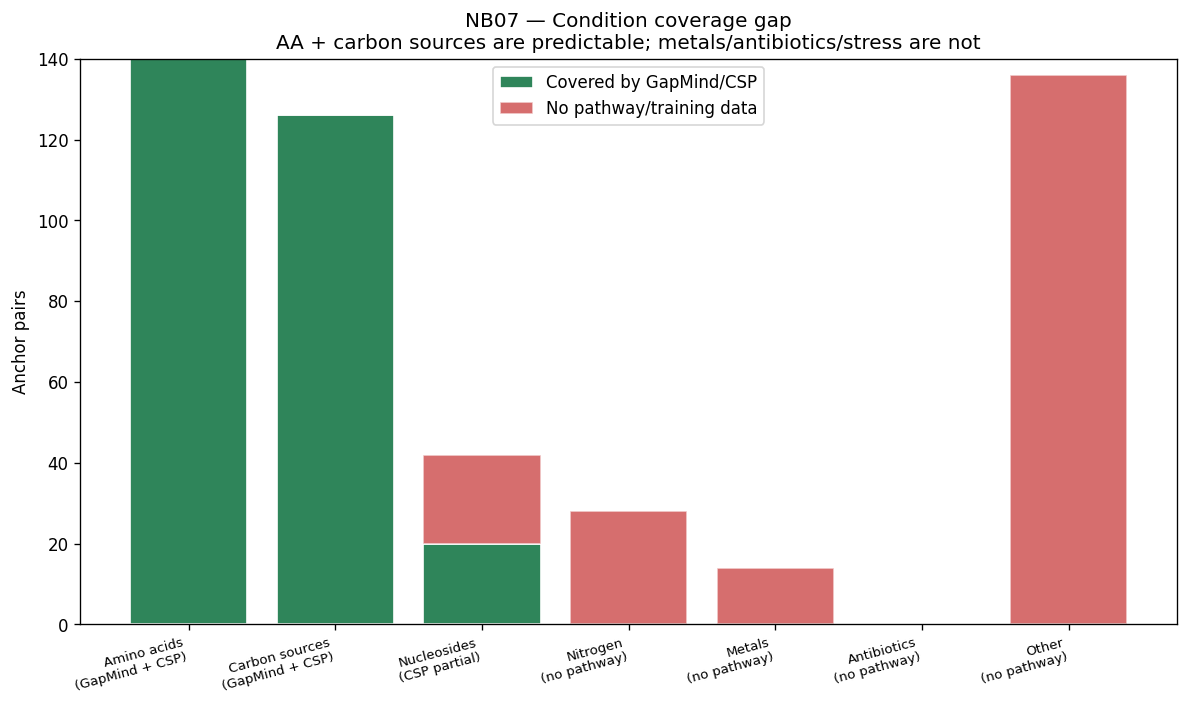

In [4]:
Image(filename=str(FIG / 'NB07_coverage_gap.png'))

### What's predictable vs not

| Condition class | GapMind? | CSP? | Predictable? |
|---|---|---|---|
| Amino acids (20 conditions) | Yes (18 pathways) | Yes (lit subset) | **Yes — AUC ~0.80** |
| Carbon sources (18 conditions) | Yes (62 pathways) | Yes (lit subset) | **Yes — AUC ~0.80** |
| Nucleosides (6 conditions) | No | Partial | Marginal |
| Nitrogen (4 conditions) | No | No | **No — no pathway/training data** |
| Metals (2 conditions) | No | No | **No — need metal resistance gene features** |
| Antibiotics (0 in anchor set) | No | No | **No — need efflux/resistance features** |
| Other (22 conditions) | No | Partial | Variable |

**The gap**: ~24% of conditions are predictable with current methods (pathway-based or data-driven). The remaining ~76% require either (a) new pathway databases (metal resistance, antibiotic resistance, nitrogen metabolism), (b) much more training data on those specific conditions, or (c) condition-specific genomic features (e.g., "count of metal efflux genes" for metal conditions, "count of beta-lactamases" for antibiotic conditions).

## 4. Implications

1. **H1 (feature resolution)**: Strongly supported. Condition-specific features (GapMind pathways, CSP condition labels) are far more predictive than generic KO presence/absence. Binary growth on amino acids/carbon sources is best predicted by **pathway completeness** (GapMind) or **condition-matched KO patterns** (CSP transfer) — not by genome scale.

2. **H2 (paradigm complementarity)**: Supported. GapMind (mechanistic, 79% precision, 97% recall, 24% coverage) and CSP-GBDT (data-driven, AUC 0.80, 23% coverage) are complementary. An ensemble would combine GapMind's high recall with CSP's broader KO-based predictions.

3. **H4 (CSP transfer)**: Supported for matched conditions (AUC 0.800 vs 0.633 ENIGMA-only). The 795-genome corpus successfully transfers condition-specific KO knowledge to ENIGMA field isolates.

4. **For the ENIGMA SFA**: Growth on common carbon sources and amino acids is predictable from genome content — a practical tool for screening field isolates without running growth assays. Growth on metals, antibiotics, and stress conditions requires purpose-built feature sets or more experimental data (active learning, Act III).

## Limitations

- **Condition matching is string-based**: Only 23% of ENIGMA conditions could be matched to CSP phenotype IDs. ChEBI-based canonicalization would likely increase this to 35-45%.
- **GapMind coverage**: Only amino acid biosynthesis and carbon source utilization. No pathways for metal tolerance, antibiotic resistance, nitrogen utilization, or nucleoside catabolism.
- **CSP lit subset only**: We trained on the 362-genome "lit" subset (literature-curated). The full CSP corpus (795 genomes, 379 conditions including pmi/atleaf/marine) would provide broader condition coverage.
- **No continuous parameter prediction**: Negative R² from NB06 not addressed — would require CSP pretraining with regression targets.
- **FB concordance not yet computed**: The biological meaningfulness of CSP-learned features remains to be validated against FB fitness data.
